In [1]:
import vector_borne_functions as vbf
import matplotlib.pyplot as plt
import numpy as np
#import seaborn as sns
#from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import xarray as xr


T = vbf.T
f = vbf.f
gammas = vbf.gammas
g = vbf.g
chis = vbf.chis
F = vbf.F
daily_mean_arrays = vbf.daily_mean_arrays
dX = vbf.dX
Vector_borne = vbf.Vector_borne



dX_Rinf = vbf.dX_Rinf_ms
Vector_borne_Rinf = vbf.Vector_borne_Rinf_ms


dX_ms = vbf.dX_ms
Vector_borne_ms = vbf.Vector_borne_ms

dX_Rinf_ms = vbf.dX_Rinf_ms

Vector_borne_Rinf_ms = vbf.Vector_borne_Rinf_ms

Vector_borne_Rinf_noise = vbf.Vector_borne_Rinf_noise








# figure 1

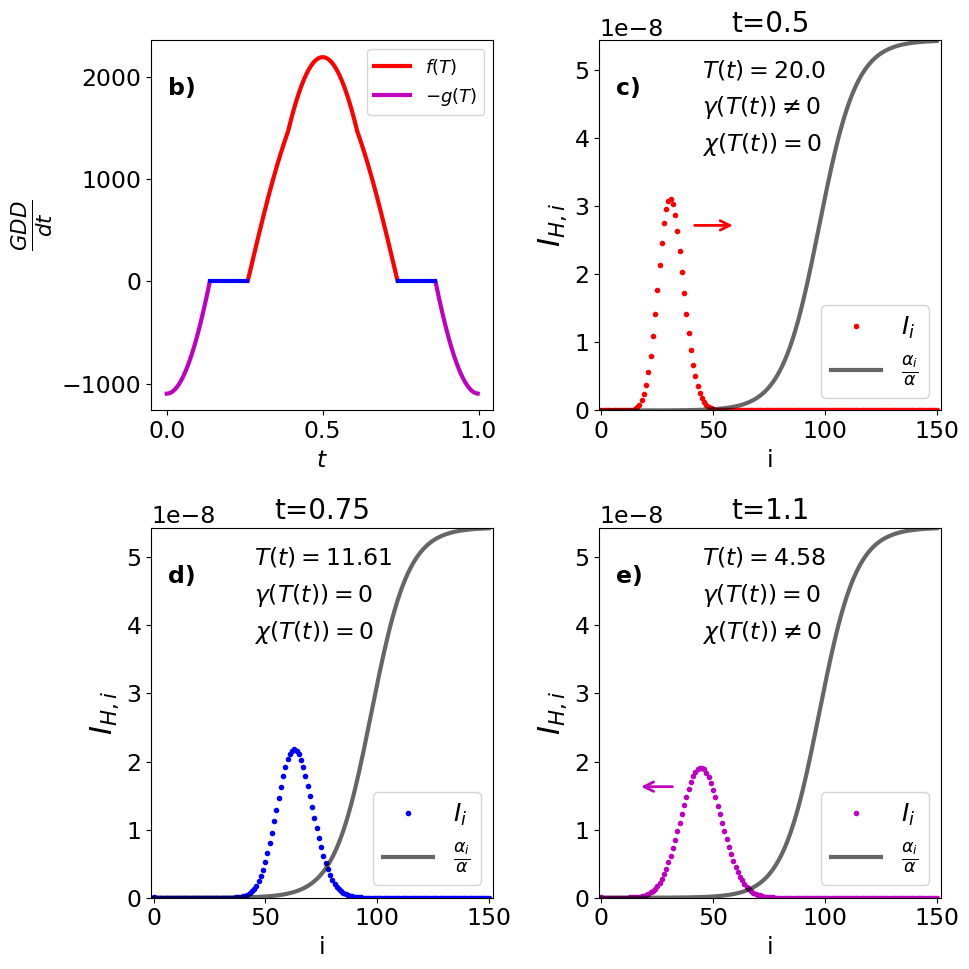

'\nfrom IPython.display import HTML\n\nHTML(open("animation/animation.html").read())\n'

In [41]:
import vector_borne_functions as vbf
import matplotlib.pyplot as plt
import numpy as np

T = vbf.T
f = vbf.f
g = vbf.g
F = vbf.F
Vector_borne = vbf.Vector_borne




MGDD_R,n = 1500.0, 150
delta_mgdd = MGDD_R/n





Alpha = 1.5
beta = 1.
Gamma = 1.
mu = 1.
delta = mu



I_H_0 = 0.01
I_v_0 = 0.0




parameters,initial_conditions=[beta,Alpha,MGDD_R,Gamma,mu,delta],[I_H_0,I_v_0]
day_fraction = 1



a = 3
b= 20



years = 10




X,times=Vector_borne(parameters,initial_conditions,years,a,b,n,day_fraction)

# get the temperature, the values of f and the values of g corresponding that temperature serie
temperature_t = T(times,a,b)
f_de_t = f(temperature_t)*365
g_de_t = g(temperature_t)*365


#get the times and the index to represent
t_frame_1 = 0.5
frame_1 = int(t_frame_1*365*day_fraction)

t_frame_2 = 0.75
frame_2 = int(t_frame_2*365*day_fraction)

t_frame_3 = 1.1
frame_3 = int(t_frame_3*365*day_fraction)



#y limits for the first grahp
total_frames = 300


y_max = np.max(X[10:n-10,:total_frames])


y_max_1 = np.max(f_de_t) +5
y_min_1 = np.min(-g_de_t) -5




#array with the points where f_de_t = 0 and g_de_t = 0
zero_progresion = np.zeros(len(f_de_t))
zero_progresion[~ ((f_de_t==0) & (g_de_t==0))] = np.nan

#set nans values where f_de_t = 0 and for the values where g_de_t = 0
f_de_t[f_de_t == 0] = np.nan
g_de_t[g_de_t == 0] = np.nan



plt.rcParams.update({'font.size': 17})

fig, ax = plt.subplots(2,2,figsize=(10,10))
ies = list(range(n+1))

#plotting the f(T(t)) and g(T(t)) for a year. Using different colors for the time intervals where each funtion is different from 0

ax[0,0].plot(times[:1*365],f_de_t[:1*365],'r',linewidth=3)
ax[0,0].plot(times[:1*365],-g_de_t[:1*365],'m',linewidth=3)
ax[0,0].plot(times[:1*365],zero_progresion[:1*365],'b',linewidth=3)


ax[0,0].set_xlabel('$t$')
ax[0,0].set_ylabel('$\\frac{GDD}{dt}$',fontsize = 22)

ax[0,0].legend(['$f(T)$','$-g(T)$'], loc = 1, fontsize = 13)

#ax[0].set_ylim(y_min_1-3,y_max_1+3)
"""
ax[0].text(0.01, 0.9*(y_max_1),
         'b)',fontsize = 15)
"""




# plotting the values of I_{H,i} for each i and the corresponding values of \mathcal{F}(mgdd_i) properly normalized

line1 = ax[0,1].plot(ies, X[:n+1,frame_1], ".",label=f'$I_i$')[0]
plot_1 = ax[0,1].plot(ies, F(np.array(ies)*delta_mgdd)*y_max, "-", color = 'k', alpha = 0.6, label='$\frac{\alpha_i}{\\alpha}$', linewidth=3)[0]




line2 = ax[1,0].plot(ies, X[:n+1,frame_2], ".",label=f'$I_i$')[0]
plot_2 = ax[1,0].plot(ies, F(np.array(ies)*delta_mgdd)*y_max, "-", color = 'k', alpha = 0.6, label='$\frac{\alpha_i}{\\alpha}$', linewidth=3)[0]



line3 = ax[1,1].plot(ies, X[:n+1,frame_3], ".",label=f'$I_i$')[0]
plot_3 = ax[1,1].plot(ies, F(np.array(ies)*delta_mgdd)*y_max, "-", color = 'k', alpha = 0.6, label='$\frac{\alpha_i}{\\alpha}$', linewidth=3)[0]


line1.set_markerfacecolor('r')
line1.set_markeredgecolor('r')


line2.set_markerfacecolor('b')
line2.set_markeredgecolor('b')



line3.set_markerfacecolor('m')
line3.set_markeredgecolor('m')





ax[0,1].set(xlim=[-1, n+2], ylim=[0,y_max], xlabel='i')
#ax[0].legend([f'temperature = {temperature_t[frame_1].round(2)}'],loc =1)

ax[0,1].legend(['$I_i$', '$\\frac{\\alpha_i}{\\alpha}$'],loc =4,  fontsize = 18)

ax[0,1].set_title(f"t={times[frame_1].round(2)}", fontsize = 20)


ax[0,1].text(0.3*n, 0.9*y_max,
         '$T(t) = 20.0$',fontsize = 17)

ax[0,1].text(0.3*n, 0.8*y_max,
         '$\\gamma(T(t)) \\neq 0$',fontsize = 17)

ax[0,1].text(0.3*n, 0.7*y_max,
         '$\\chi(T(t)) = 0$',fontsize = 17)
"""
ax[1].text(0.01*n, 0.9*y_max,
         'c)',fontsize = 15)
"""


ax[0,1].annotate(
    '', xy=(0.4*n, 0.5*y_max), xytext=(0.27*n, 0.5*y_max),
    arrowprops=dict(arrowstyle='->', color='r', lw=2)
)






ax[1,0].set(xlim=[-1, n+2], ylim=[0,y_max])
#ax[2].legend([f'temperature = {temperature_t[frame_2].round(2)}'],loc =1)
ax[1,0].legend(['$I_i$', '$\\frac{\\alpha_i}{\\alpha}$'],loc =4,  fontsize = 18)
ax[1,0].set_title(f"t={times[frame_2].round(2)}", fontsize = 20)

ax[1,0].text(0.3*n, 0.9*y_max,
         '$T(t) = 11.61$',fontsize = 17)

ax[1,0].text(0.3*n, 0.8*y_max,
         '$\\gamma(T(t)) = 0$',fontsize = 17)

ax[1,0].text(0.3*n, 0.7*y_max,
         '$\\chi(T(t)) = 0$',fontsize = 17)

"""
ax[2].text(0.01*n, 0.9*y_max,
         'd)',fontsize = 15)
"""








ax[1,1].set(xlim=[-1, n+2], ylim=[0,y_max])
#ax[3].legend([f'temperature = {temperature_t[frame_3].round(2)}'],loc =1)
ax[1,1].legend(['$I_i$', '$\\frac{\\alpha_i}{\\alpha}$'],loc =4, fontsize = 18)
ax[1,1].set_title(f"t={times[frame_3].round(2)}", fontsize = 20)



ax[1,1].text(0.3*n, 0.9*y_max,
         '$T(t) = 4.58$',fontsize = 17)

ax[1,1].text(0.3*n, 0.8*y_max,
         '$\\gamma(T(t)) = 0$',fontsize = 17)

ax[1,1].text(0.3*n, 0.7*y_max,
         '$\\chi(T(t)) \\neq 0$',fontsize = 17)

"""
ax[3].text(0.01*n, 0.9*y_max,
         'e)',fontsize = 15)
"""



ax[1,1].annotate(
    '', xy=(0.11*n, 0.3*y_max), xytext=(0.22*n, 0.3*y_max),
    arrowprops=dict(arrowstyle='->', color='m', lw=2)
)

ax[0,1].set_xlabel('i')
ax[1,0].set_xlabel('i')
ax[1,1].set_xlabel('i')

ax[0,1].set_ylabel('$I_{H,i}$', fontsize = 22)
ax[1,0].set_ylabel('$I_{H,i}$', fontsize = 22)
ax[1,1].set_ylabel('$I_{H,i}$', fontsize = 22)



#ax[0,1].get_yaxis().set_visible(False)
#ax[1,0].get_yaxis().set_visible(False)
#ax[1,1].get_yaxis().set_visible(False)

"""
ax[1].sharey(ax[2])

ax[2].sharey(ax[3])
"""

labels = ["b)", "c)", "d)", "e)"]

# Add labels to each subplot
for i in range(2):
    for j in range(2):
        axes = ax[i, j]
        # Put label in top-left corner (inside axes)
        axes.text(
            0.05, 0.9,           # x, y in axes coordinates (0-1)
            labels[i*2 + j],
            transform=axes.transAxes,  # coordinates relative to axes
            fontsize=17,
            fontweight='bold',
            va='top', ha='left',
            color='black',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)  # optional white box for visibility
        )


plt.tight_layout()
plt.savefig(f"figures/figure_1.png", dpi=300, bbox_inches="tight")


plt.show()

"""
from IPython.display import HTML

HTML(open("animation/animation.html").read())
"""

# figure 2

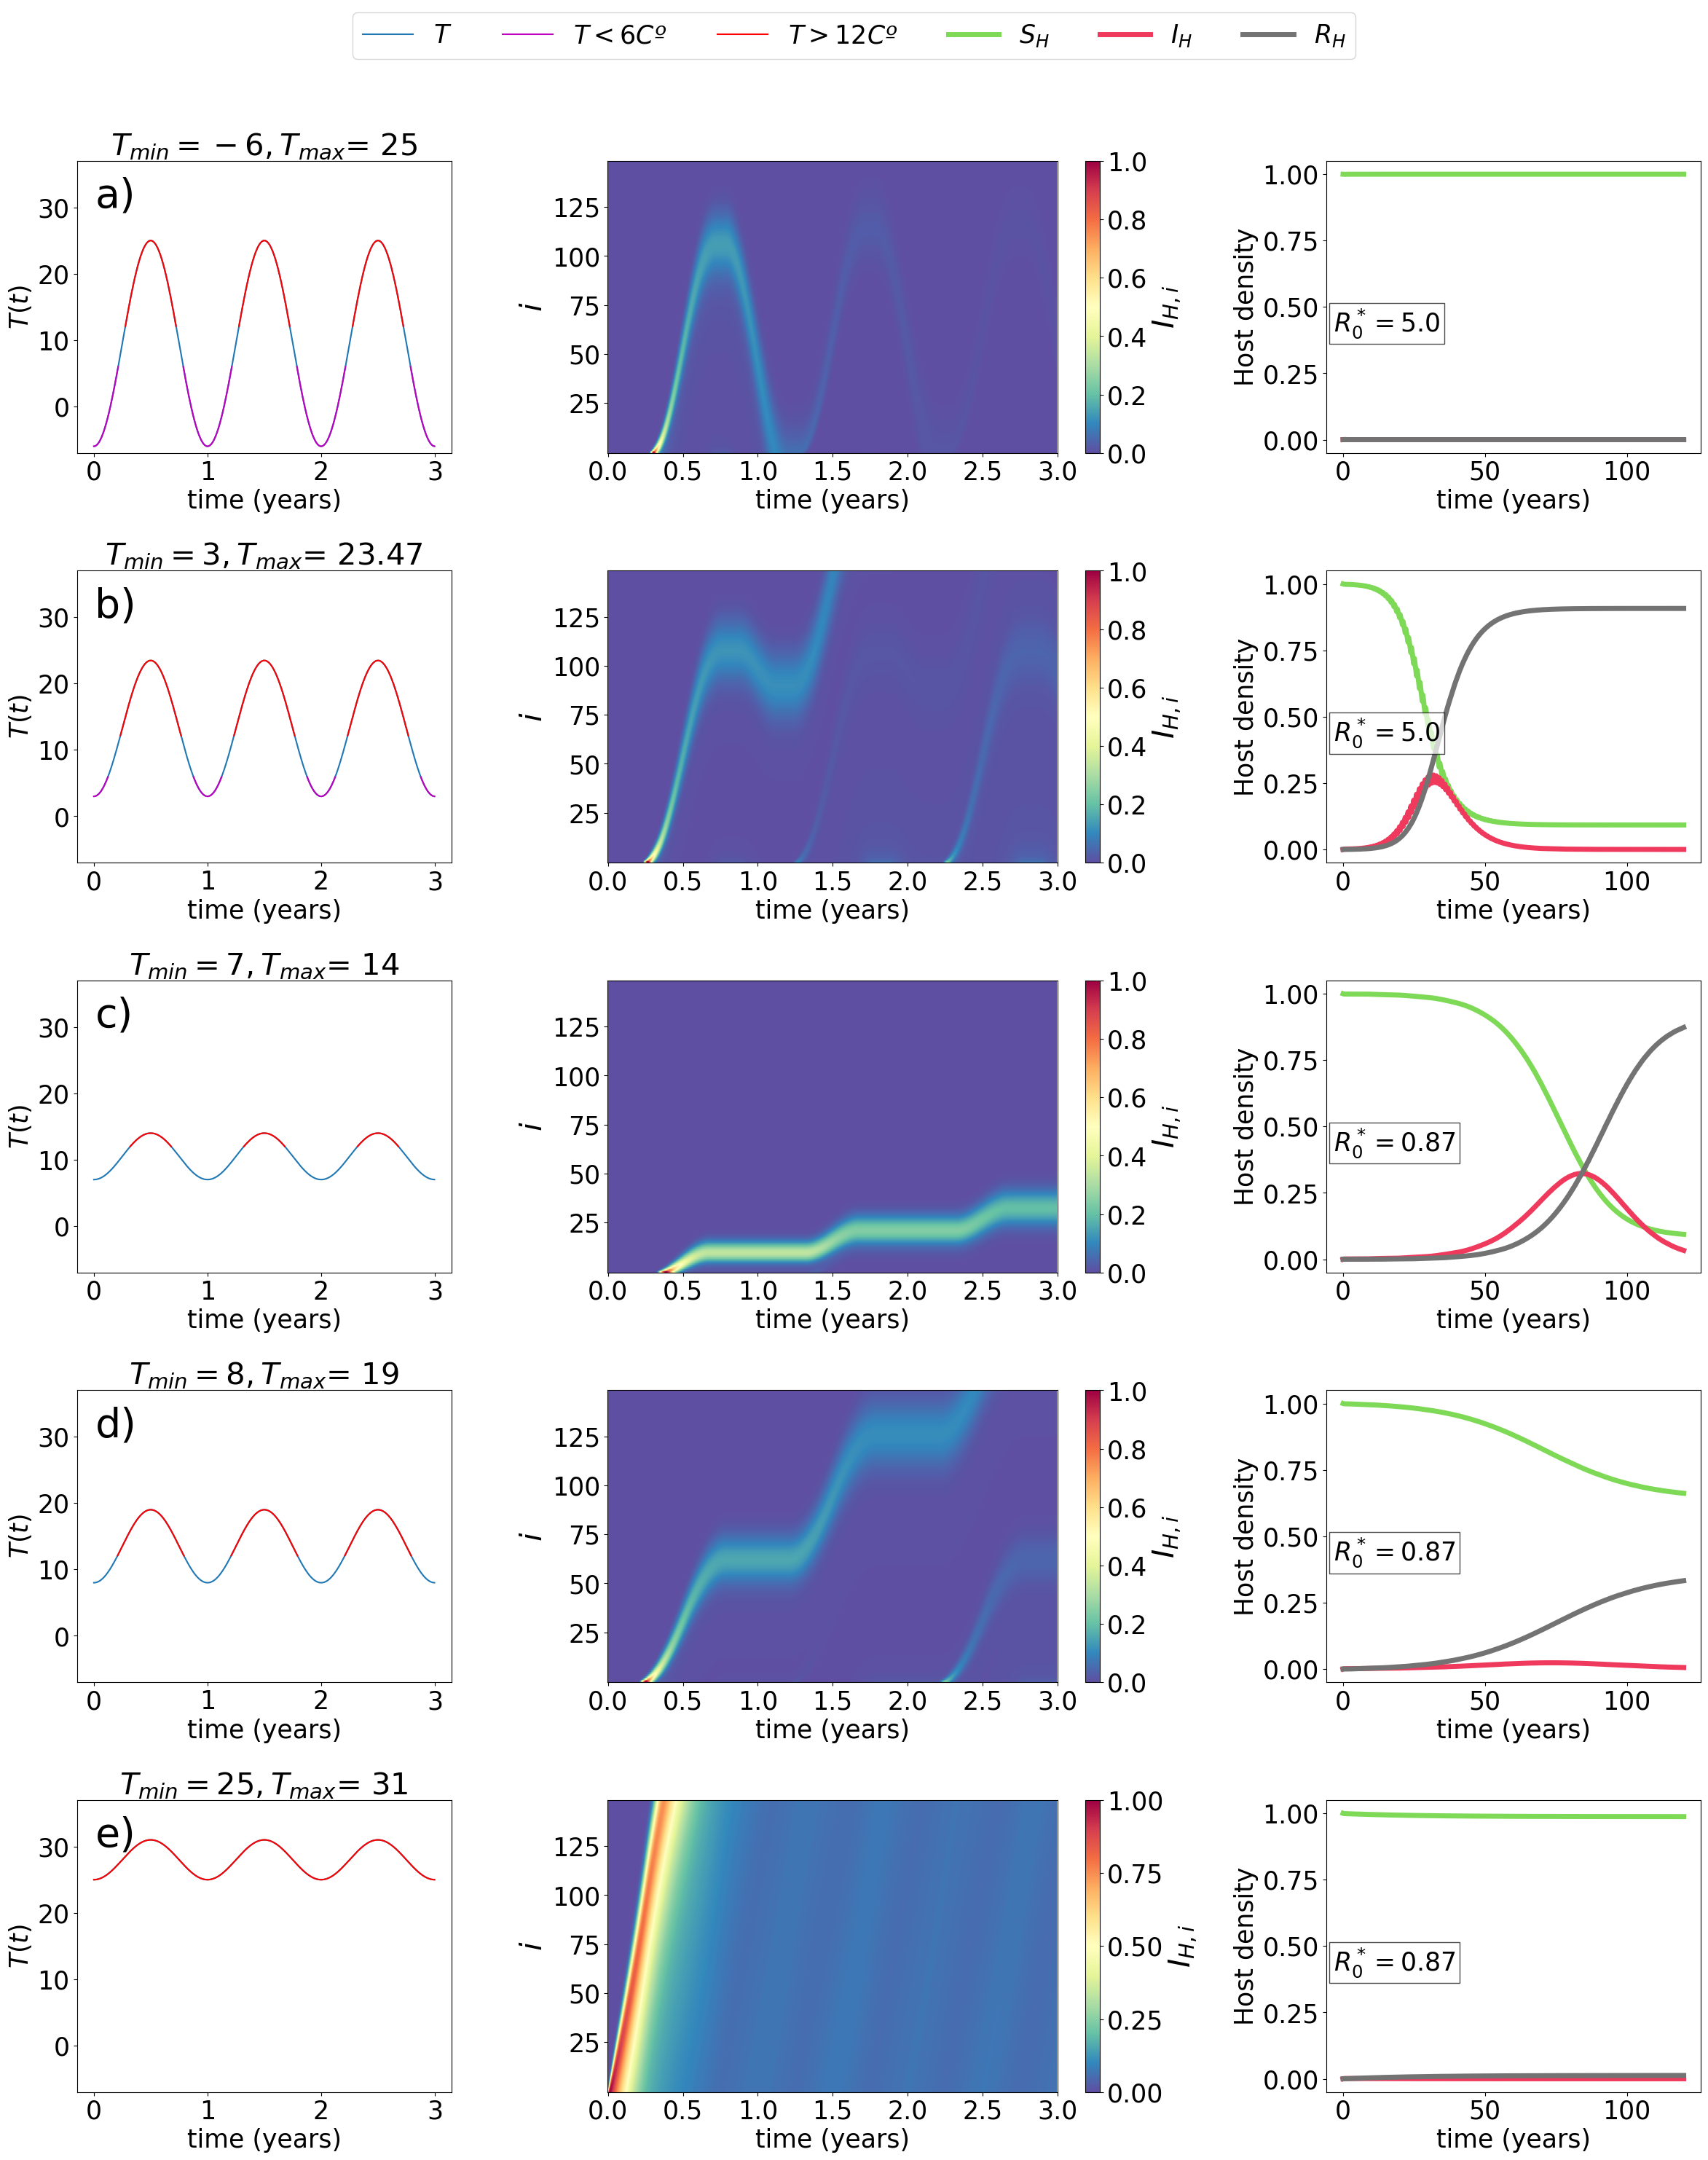

In [30]:
import vector_borne_functions as vbf
import matplotlib.pyplot as plt
import numpy as np

Vector_borne = vbf.Vector_borne
T = vbf.T

MGDD_R,n = 1500.0, 150
delta_mgdd = MGDD_R/n

day_fraction = 1


# list of parameters: (T_min,T_max,Alpha,beta,Gamma,mu)
a_b_s = (-6, 25 , 4.015, 2., 0.2, 8.03), (3, 23.47 , 4.015, 2., 0.2, 8.03), (7, 14, 4.015, 0.65, 0.5, 6.), (8, 19, 4.015, 0.65, 0.5, 6.), (25, 31, 4.015, 0.65, 0.5, 6.)

#initial conditions
I_H_0 = 0.
I_v_0 = 0.01

initial_conditions=[I_H_0,I_v_0]

# time limit for represent the temperature and the infected host density
year_limit = 3

#time limit for simulations
years = 120


plt.rcParams.update({'font.size': 25})


#fig, ax = plt.subplots(5,3,figsize=(30,30))
fig, ax = plt.subplots(5, 3, figsize=(8*3,6*5),
                       gridspec_kw={"width_ratios": [1, 1.5, 1]})

panel_label = ['a)','b)','c)','d)','e)']

s=0

#for each parameter combination
for a, b, Alpha, beta, Gamma , mu in a_b_s:

    delta = mu
    parameters = [beta,Alpha,MGDD_R,Gamma,mu,delta]

    # R_0^*
    R_s = Alpha*beta/(mu*Gamma)

    
    X,times=Vector_borne(parameters,initial_conditions,years,a,b,n,day_fraction)




    #T(t,T_min,T_max)
    T_t = T(times,a,b)

    #temperatures without disease progression
    T_blue = np.copy (T_t)
    T_blue [(T_blue >6)] = np.nan

    #temperatures with disease progression
    T_red = np.copy (T_t)
    T_red[(T_red <12)] = np.nan


    #plot the temperatures corresponding to each regime
    t_1_plot = ax[s,0].plot(times[:year_limit*365],T_t[:year_limit*365])
    t_2_plot = ax[s,0].plot(times[:year_limit*365],T_blue[:year_limit*365],color = "m")
    t_3_plot = ax[s,0].plot(times[:year_limit*365],T_red[:year_limit*365],color = "r")
    
    ax[s,0].set_xlabel("time (years)")
    ax[s,0].set_ylim(-7,37)

    #ax[s,0].legend(["$T \\in [6 Cº,12Cº]$","$T< 6 Cº$","$T \\in [12 Cº,35Cº]$"],fontsize = 15)
    ax[s,0].set_ylabel("$T(t)$")
    
    ax[s,0].text(0.01, 30,
         f'{panel_label[s]}',fontsize = 40)
    
    ax[s,0].set_title("$T_{min}$" + f"$={a},$" + "$T_{max}$" f"= ${b}$")




    # array with the normaliced infected host density at each time (I_{H,i}(t)/max(I_{H,i}))
    X_rep = X[1:n,:year_limit*365*day_fraction]
    X_rep = X_rep/np.max(X_rep)
    
    im = ax[s,1].imshow(X_rep,aspect="auto",cmap = 'Spectral_r', origin = 'lower')
    cb = plt.colorbar(im, ax=ax[s,1])
    cb.set_label("$I_{H,i}$",fontsize = 30)

    ax[s,1].set_xticks(list(np.linspace(0,year_limit*365,19)[::3]),list(np.linspace(0,year_limit,19)[::3]))
    ax[s,1].set_yticks(range(25,n,25))
    ax[s,1].set_xlabel("time (years)")
    



    # plotting I_H(t) = \sum_i I_{H,i}(t)
    S_plot = ax[s,2].plot(times,X[-4],"#7ed957",linewidth = 5)
    I_plot = ax[s,2].plot(times,np.sum(X[:n+1,:],axis=0),"#ef3a5d",linewidth = 5)
    R_plot = ax[s,2].plot(times,X[-3],"#737373",linewidth = 5)

    ax[s,2].set_xlabel("time (years)")
    ax[s,2].set_ylabel("Host density")
    
    ax[s,2].text(
    0.02, 0.5,
    f"$R_0^* = {np.round(R_s,2)}$",
    transform=ax[s,2].transAxes,
    va="top",
    bbox=dict(facecolor="white", alpha=0.7))

    #ax[s,2].legend(["$S_H$","$I_H$","$R_H$","$S_v$","$I_v$"], fontsize = 22, loc = 
                  #1)
    ax[s,1].set_ylabel("$i$",fontsize = 30)

    if s == 0:
        handles = [t_1_plot, t_2_plot, t_3_plot,S_plot ,I_plot ,R_plot]
        labels = ["$T$","$T< 6 Cº$","$T> 12 Cº$","$S_H$","$I_H$","$R_H$"]

    

    s+=1

handles = [x[0] for x in handles]

fig.legend(
    handles,
    labels,
    loc="upper center",  # above all subplots
    ncol=6,
    fontsize=25
)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space at top for legend

plt.savefig(f"figures/figure_2.pdf", dpi=300, bbox_inches="tight")
plt.show()

# figure 3

/home/juancarlosrc/.conda/envs/compa/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/juancarlosrc/.conda/envs/compa/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/juancarlosrc/.conda/envs/compa/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/juancarlosrc/.conda/envs/compa/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


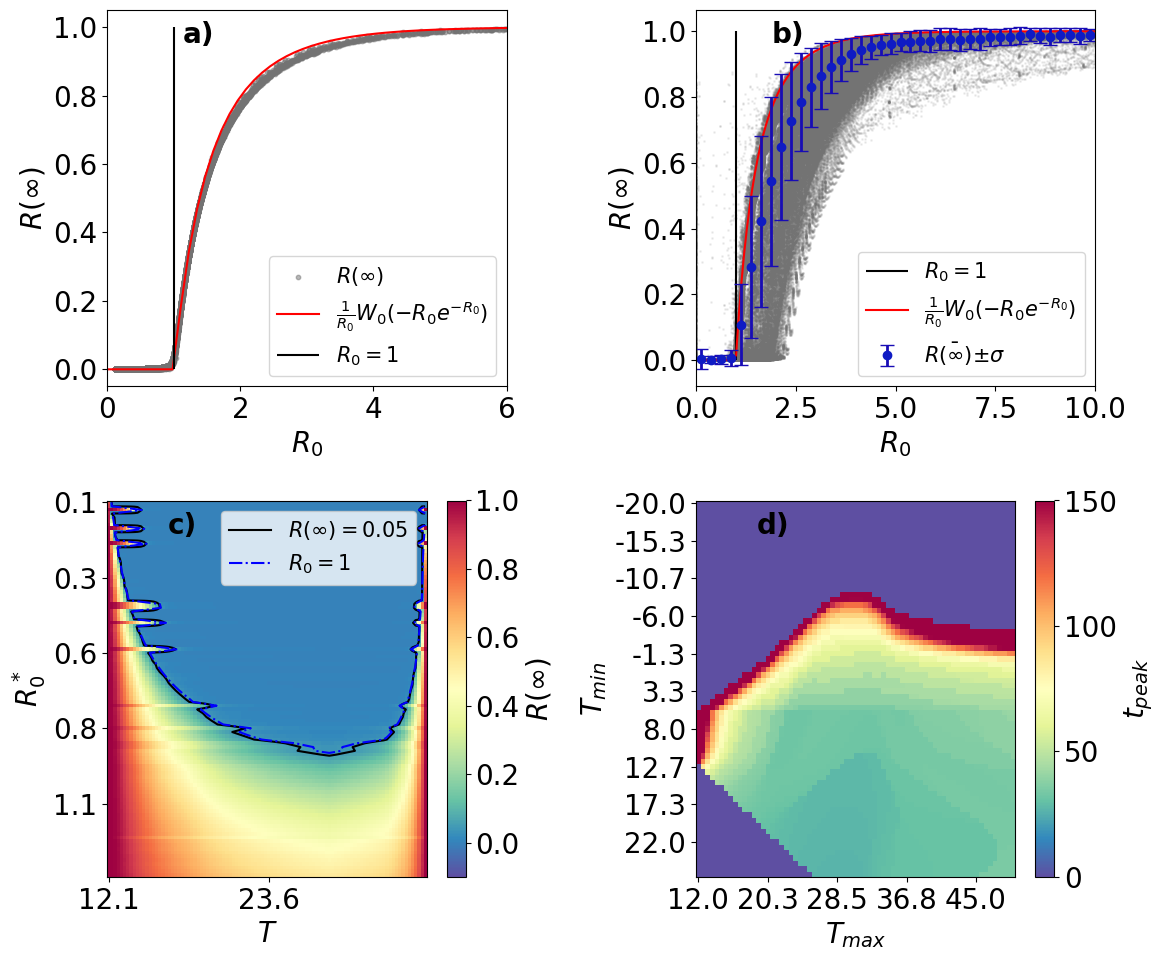

In [32]:
from scipy.special import lambertw
import re
import numpy as np
import matplotlib.pyplot as plt


flat_r_0 = np.loadtxt('R_0_sinusoidal_temperature/flat_r_0.txt')
flat_r_infty = np.loadtxt('R_0_sinusoidal_temperature/flat_r_infty.txt')

r_0_constant = np.loadtxt('R_0_constant_temperature/r_0_constant.txt')
r_infty_constant = np.loadtxt('R_0_constant_temperature/r_infty_constant.txt')
temperatures = np.loadtxt('R_0_constant_temperature/temperatures.txt')
r_star_values = np.loadtxt('R_0_constant_temperature/r_star_values.txt')


peak_time_array_name = 'peak_time_values_6.0_1.0_1.0_1.0_1.0_1.0.txt'
peak_time_folder_name = 'dimension_70_arage_-20_26_brange_12_50_dfraction_10_n200_Iv'
peak_time_folder_path = 'R_0_sinusoidal_temperature/peak_time_arrays/' + peak_time_folder_name

peak_time_array = np.loadtxt(peak_time_folder_path + '/' + peak_time_array_name)

dimension_ab, a_min, a_max,b_min,b_max = [int(x) for x in re.findall(r"[-+]?\d*\.?\d+", peak_time_folder_name)][:5]

a_values = np.linspace(a_min,a_max,dimension_ab)
b_values = np.linspace(b_min,b_max,dimension_ab)



r_0_vals = np.linspace(0.001,10,150)
lamb_function = 1+1/r_0_vals*lambertw(-r_0_vals*np.exp(-r_0_vals ))


# Build mask using both arrays
mask = (~np.isnan(flat_r_0)) & (~np.isnan(flat_r_infty))

# Apply mask
R_0_masked = flat_r_0[mask]
R_inf_masked = flat_r_infty[mask]

# Define your bins for R_0
num_bins = 40
bins = np.linspace(R_0_masked.min(), 10, num_bins + 1)

# Get bin index for each R_0 value
bin_indices = np.digitize(R_0_masked, bins)  # returns 1-based indices

# Group R_inf values according to R_0 bins
grouped_R_inf = []
for i in range(1, len(bins)):  # bins 1..num_bins

    group = R_inf_masked[bin_indices == i]
    grouped_R_inf.append(group)

# compute mean R_inf per R_0 bin
mean_R_inf_per_bin = np.array([g.mean() if len(g) > 0 else np.nan for g in grouped_R_inf])
"""
#  print result
for i, g in enumerate(grouped_R_inf):
    print(f"Bin {i+1} ({bins[i]:.2f}-{bins[i+1]:.2f}): {len(g)} points, mean R_inf={mean_R_inf_per_bin[i]:.3f}")

"""


# Compute mean and standard deviation of R_inf per bin
mean_R_inf = np.array([g.mean() if len(g) > 0 else np.nan for g in grouped_R_inf])
std_R_inf = np.array([g.std() if len(g) > 0 else np.nan for g in grouped_R_inf])

# Bin centers
bin_centers = [(bins[i]+bins[i+1])/2 for i in range(len(grouped_R_inf))]






plt.rcParams.update({'font.size': 20})

fig, ax = plt.subplots(2,2,figsize=(12,10))

#---------------------------------------------------------------------



dimension = np.shape(r_infty_constant)[0]
    
ax[0,0].scatter(r_0_constant, r_infty_constant, s=10, c = "#737373",alpha = 0.5, label = '$R(\\infty)$')

Rs_0s = np.linspace(0.001,6)
ax[0,0].plot(Rs_0s, 1 + 1/Rs_0s*lambertw(-Rs_0s*np.exp(-Rs_0s)),"r", label = "$\\frac{1}{R_0}W_0(-R_0e^{-R_0})$")

ax[0,0].vlines(x = 1, ymin = 0, ymax = 1, color = 'k', label = "$R_0 = 1$" )


ax[0,0].set_xlabel('$R_{0}$')
ax[0,0].set_ylabel('$R(\\infty)$')
ax[0,0].legend( loc =4,fontsize =15)
        
ax[0,0].set_xlim(0,6)  
"""
cbar = fig.colorbar(sc, ax=ax[0], orientation='vertical')
cbar.set_label("$f(T)$") 
"""






im_1 = ax[1,0].imshow(r_infty_constant,vmin = -0.1, vmax = 1 ,aspect="auto",cmap = 'Spectral_r')
colorbar_1 = plt.colorbar(im_1, ax=ax[1,0])
colorbar_1.set_label('$R(\\infty)$')



ax[1,0].set_xlabel("$T$")
ax[1,0].set_ylabel("$R_0^*$")
        
ax[1,0].set_yticks(list(range(dimension)[::5]),list(np.round(r_star_values,1)[::5]))
ax[1,0].set_xticks(list(range(dimension)[::5]),list(np.round(temperatures,1)[::5]))
#axes[0].set_title('$R_{\\infty}$',fontsize = 15)
#-------------------------------------------------------------------------------



color_line = 'black'

level_1 = 0.05
contour_1 = ax[1,0].contour(r_infty_constant, levels=[level_1], colors=color_line, linewidths=1.5)
#contour_1.collections[0].set_label(f'$R(\\infty) > {level_1}$')




color_line_1 = 'blue'
level_2 = 1
contour_2 = ax[1,0].contour(r_0_constant, levels=[level_2], colors= color_line_1, linewidths=1.5,linestyles='-.' )
#contour_2.collections[0].set_label(f'$R_0 > {level_2}$')



# Crear handles y labels para la leyenda
handles_1 = [
    plt.Line2D([], [], color=color_line, lw=1.5, label=f'$R(\\infty) = {level_1}$'),
    plt.Line2D([], [], color=color_line_1, lw=1.5,
        linestyle='-.', label=f'$R_0 = {level_2}$')
]

handles_2 = [
    plt.Line2D([], [], color=color_line, lw=1.5, label=f'$R_0 = {level_2}$')
]

ax[1,0].legend(handles=handles_1, loc='upper right', fontsize = 15)



#axes[0].legend(loc='upper right')


ax[1,0].xaxis.set_major_locator(plt.AutoLocator())
ax[1,0].yaxis.set_major_locator(plt.AutoLocator())






ax[0,1].scatter(flat_r_0,flat_r_infty, s=4, marker = '.' , c= "#737373",alpha = 0.1)

ax[0,1].vlines(x = 1, ymin = 0, ymax = 1,color = "k", label = "$R_0 = 1$")

ax[0,1].plot(r_0_vals,lamb_function,"r", label = "$\\frac{1}{R_0}W_0(-R_0e^{-R_0})$")

ax[0,1].set_xlim(0,10)

ax[0,1].set_xlabel("$R_0$")
ax[0,1].set_ylabel("$R(\\infty)$")



ax[0,1].errorbar(
    bin_centers, 
    mean_R_inf, 
    yerr=std_R_inf,       # vertical error bars
    fmt='o',              # marker style
    color="#0F1BC4", 
    ecolor="#180CB5",   # color of the error bars
    elinewidth=2, 
    capsize=5,            # little horizontal caps on error bars
    label="$\\bar{R(\\infty)} ± \\sigma$"
)

ax[0,1].legend(fontsize = 15)






im_2 = ax[1,1].imshow(peak_time_array[:,1:]*5, vmin = -0.05, vmax = 150, aspect="auto", cmap = 'Spectral_r', animated=True)
colorbar_2 = plt.colorbar(im_2, ax=ax[1,1])
colorbar_2.set_label('$t_{peak}$')
    
        
ax[1,1].set_xlabel("$T_{max}$")
ax[1,1].set_ylabel("$T_{min}$")


ax[1,1].set_yticks(list(range(dimension_ab)[::7]),list(np.round(a_values,1)[::7]))
ax[1,1].set_xticks(list(range(dimension_ab)[::15]),list(np.round(b_values,1)[::15]))


letters = [f'{chr(97+i)})' for i in range(ax.size)]
i = 0

letters = [f'{chr(97+i)})' for i in range(ax.size)]
i = 0

for row in ax:
    for axes in row:
        axes.text(0.19, 0.97, letters[i],
                transform=axes.transAxes,
                fontsize=20, fontweight='bold',
                va='top', ha='left')
        i += 1

plt.tight_layout()

plt.savefig(f"figures/figure_3.png", dpi=300, bbox_inches="tight")

plt.show()

# figure 4

/tmp/ipykernel_563971/3178446933.py:203: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


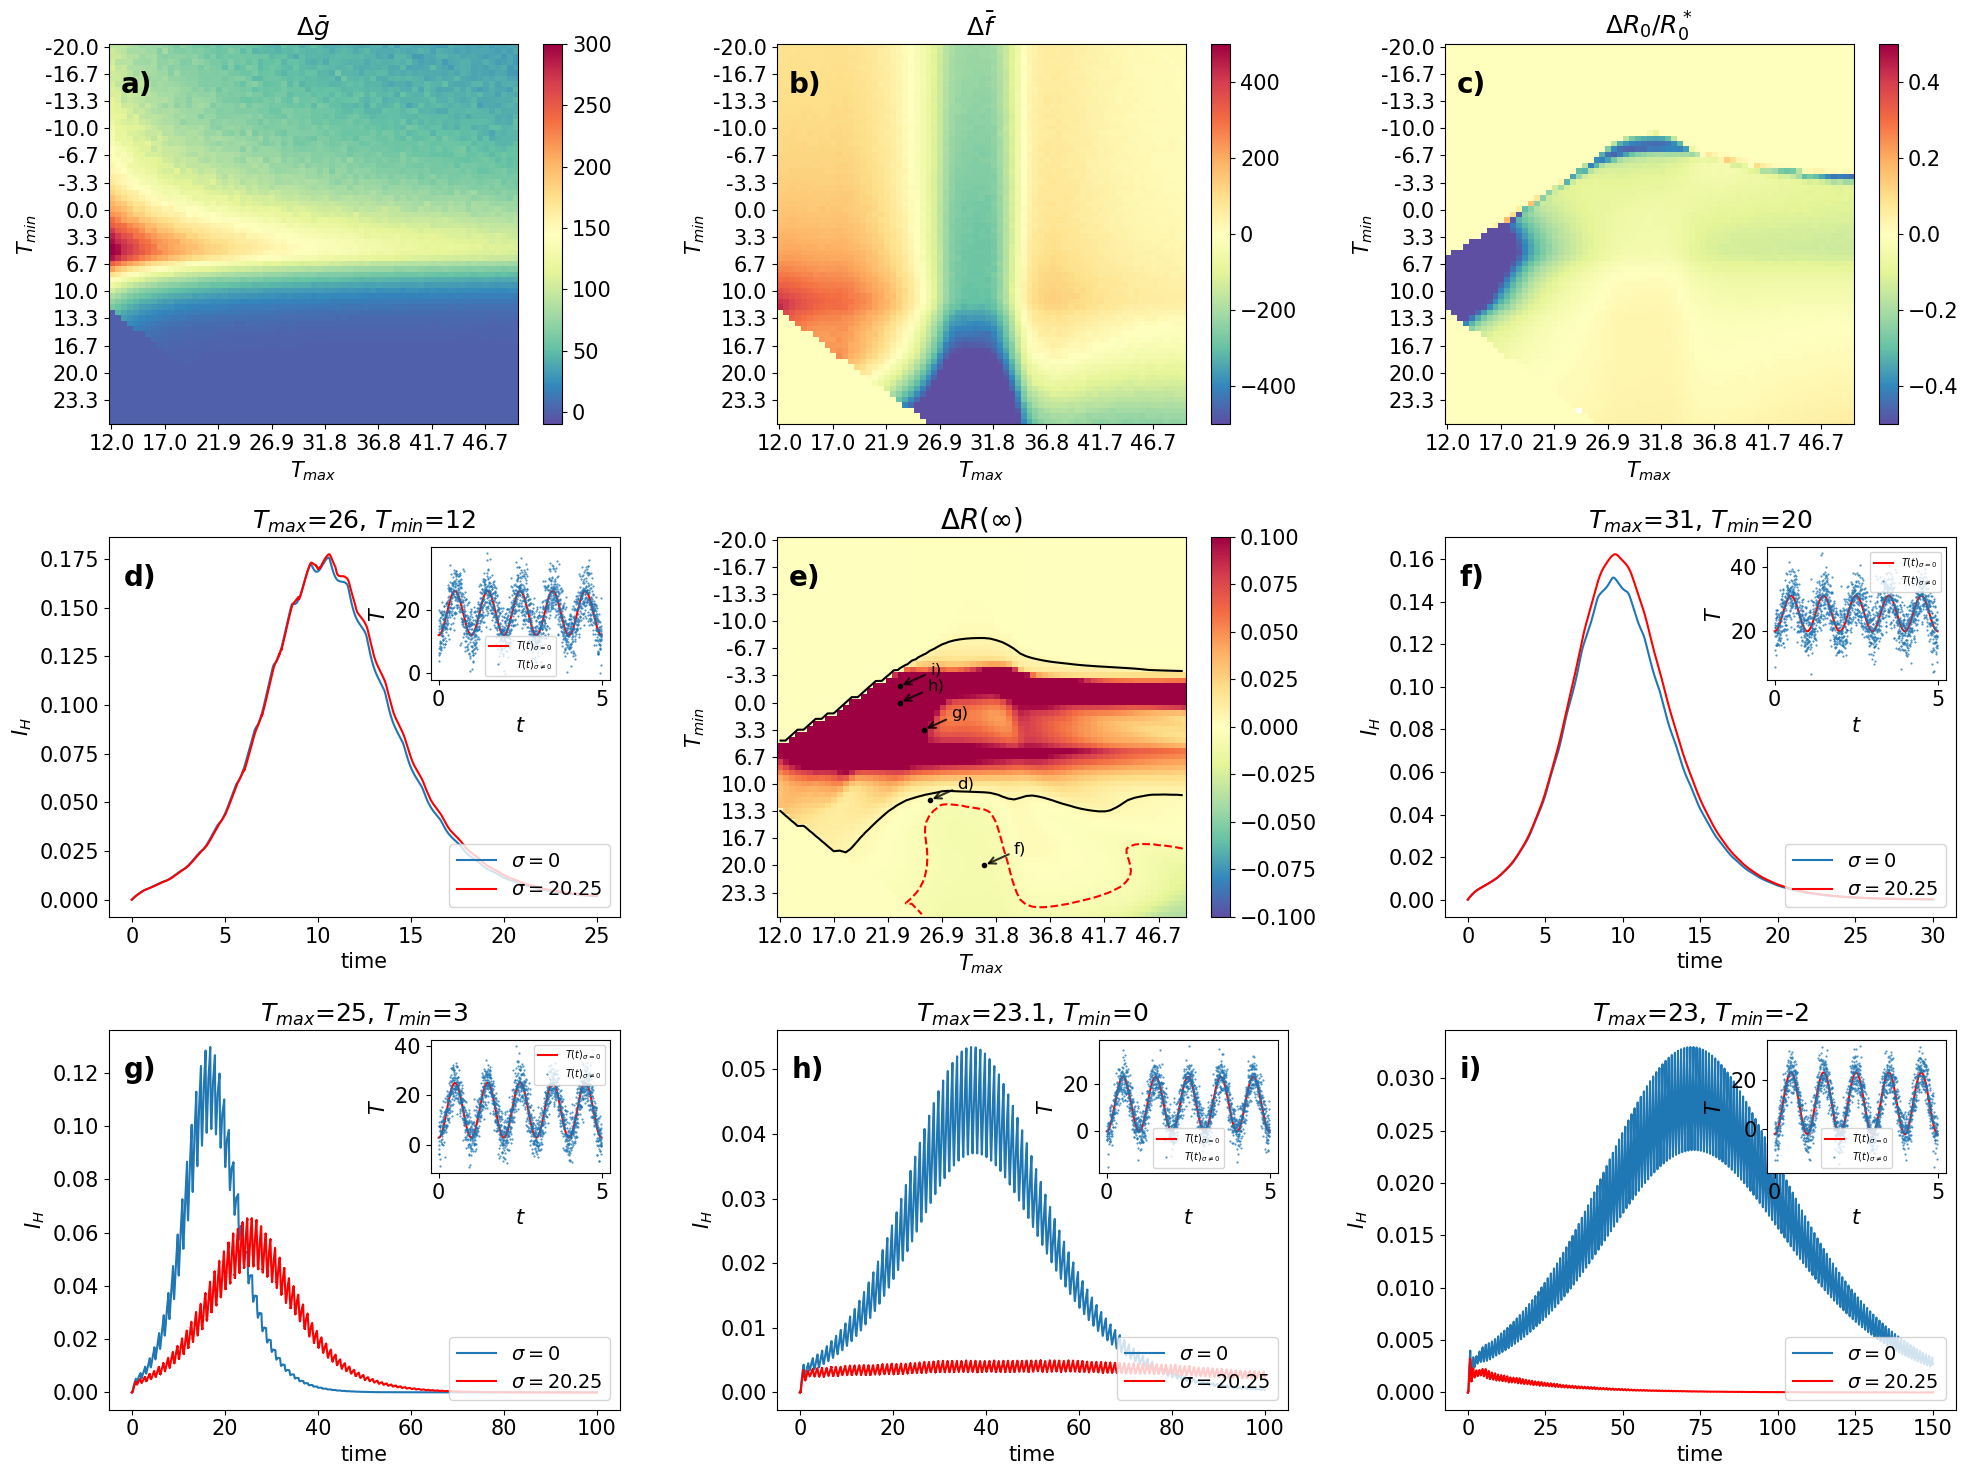

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import re
import vector_borne_functions as vbf
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

Vector_borne_Rinf_noise = vbf.Vector_borne_Rinf_noise
Vector_borne_Rinf_ms = vbf.Vector_borne_Rinf_ms
T = vbf.T


folder_name = 'dimension_70_arage_-20_26_brange_12_50_dfraction_5_n200_Iv_noise'

dimension_ab, a_min, a_max,b_min,b_max = [int(x) for x in re.findall(r"[-+]?\d*\.?\d+", folder_name)][:5]

a_values = np.linspace(a_min,a_max,dimension_ab)
b_values = np.linspace(b_min,b_max,dimension_ab)


def plot_array_subplot(ax,R_inf_array, a_values, b_values, dimension,v_min,v_max):

    im_1 = ax.imshow(R_inf_array, vmin = v_min, vmax = v_max, aspect="auto", cmap = 'Spectral_r', animated=True)
    colorbar_1 = plt.colorbar(im_1, ax=ax)
    
        
    ax.set_xlabel("$T_{max}$")
    ax.set_ylabel("$T_{min}$")
        
    ax.set_yticks(list(range(dimension)[::5]),list(np.round(a_values,1)[::5]))
    ax.set_xticks(list(range(dimension)[::9]),list(np.round(b_values,1)[::9]))
    

delta_r_inf = np.loadtxt('adding_noise/delta_r_inf.txt')
delta_f_m = np.loadtxt('adding_noise/delta_f_m.txt')
delta_g_m = np.loadtxt('adding_noise/delta_g_m.txt')
delta_r_0_m = np.loadtxt('adding_noise/delta_r_0_m.txt')


#----------------------------------------------
MGDD_R,n = 1500.0, 200
#----------------------------------------------

dimension = 70


panels = [(1,0),(1,2),(2,0),(2,1),(2,2)]
a_b_combinations = [(12,26),(20,31),(3,25),(0,23.1),(-2,23)]
fig_label_a_b = ['d)','f)','g)','h)','i)']
max_year = [25.,30.,100.,100.,150.]

sigma = 20.25


#----------------------------------------------

Alpha = 2.5
beta = 1.
Gamma = 1.
mu = 1.
delta = mu

parameters = [beta,Alpha,MGDD_R,Gamma,mu,delta]

N_H = 1
N_v = 1

#----------------------------------------------
I_H_0 = 0.
I_v_0 = 0.01

initial_conditions= [I_H_0,I_v_0]
#----------------------------------------------
day_fraction = 5






plt.rcParams.update({'font.size': 15})

fig, axes = plt.subplots(3, 3, figsize=(20, 15))

max_year_to_temp = 5


plot_array_subplot(axes[1,1], -delta_r_inf[:,1:], a_values, b_values, dimension,-0.1,0.1)
cont_1 = axes[1,1].contour(-delta_r_inf[:,1:], levels=[0.005], colors='k')
cont_2 = axes[1,1].contour(-delta_r_inf[:,1:], levels=[-0.005], colors='r')
axes[1,1].set_title('$\\Delta R(\\infty)$',fontsize = 20)






plot_array_subplot(axes[0,0], delta_g_m[:,1:], a_values, b_values, dimension,-10,300)
plot_array_subplot(axes[0,1], delta_f_m[:,1:], a_values, b_values, dimension,-500,500)
plot_array_subplot(axes[0,2], delta_r_0_m[:,1:], a_values, b_values, dimension,-0.5,0.5)


axes[0,0].set_title('$\\Delta \\bar{g}$')
axes[0,1].set_title('$\\Delta \\bar{f}$')
axes[0,2].set_title('$\\Delta R_0/R_0^*$')


n_panels = len(panels)

for k in range(n_panels):

    a,b = a_b_combinations[k]
    panel = panels[k]

    years = max_year[k]

    X,times = Vector_borne_Rinf_ms(parameters,initial_conditions,years,a,b,n,day_fraction,N_H,N_v)
    X_,times_,T_t_n=Vector_borne_Rinf_noise(parameters,initial_conditions,years,a,b,sigma,n,day_fraction,N_H,N_v)

    T_t = T(times_,a,b)


    
    ax_inset = inset_axes(axes[panel], width="35%", height="35%", loc="upper right")
    ax_inset.plot(times_[:max_year_to_temp*365], T_t[:max_year_to_temp*365],"r",label = "$T(t)_{\\sigma = 0}$")
    ax_inset.plot(times_[:max_year_to_temp*365],T_t_n[:max_year_to_temp*365],".",markersize = 1,alpha = 0.9, label = "$T(t)_{\\sigma \\neq 0}$")
    ax_inset.set_xlabel("$t$")
    ax_inset.set_ylabel("$T$")
    ax_inset.legend(fontsize = 7)
    

    axes[panel].plot(times, np.sum(X[:n+1,:],axis=0),label = '$\\sigma=0$')

    axes[panel].plot(times_, np.sum(X_[:n+1,:],axis=0),'r', label = f'$\\sigma={sigma}$')

    axes[panel].set_xlabel('time',fontsize = 15)
    axes[panel].set_ylabel('$I_H$',fontsize = 15)
    axes[panel].legend(fontsize = 14,loc = 4)

    axes[panel].set_title('$T_{max}$' + f'={b},' + ' ' + '$T_{min}$' + f'={a}')

    c_1 = np.argmin(np.abs(a_values-a))
    c_2 = np.argmin(np.abs(b_values-b))

    """
    axes[1,1].text(
    c_2, c_1,        # x, y position
    f"({b},{a})",      # text
    color="black",
    fontsize=10,
    ha="center",     # horizontal alignment
    va="center",
    alpha = 0.8
)
    """
    """
    axes[1,1].text(
    c_2, c_1,        # x, y position
    fig_label_a_b[k],      # text
    color="black",
    fontsize=12,
    ha="center",     # horizontal alignment
    va="center",
    alpha = 0.8
)
   """ 

    axes[1,1].annotate(
    fig_label_a_b[k],          # text
    xy=(c_2, c_1),             # point to annotate
    xytext=(c_2 + 6, c_1 -3), # position of the label
    textcoords='data',
    fontsize=12,
    color="black",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        lw=1.5,
        alpha=0.8
    ))

    axes[1,1].plot(c_2, c_1, 'o', color='black', markersize=3, zorder=5)




letters = [f'{chr(97+i)})' for i in range(axes.size)]
i = 0

letters = [f'{chr(97+i)})' for i in range(axes.size)]
i = 0

for row in axes:
    for ax in row:
        ax.text(0.03, 0.93, letters[i],
                transform=ax.transAxes,
                fontsize=20, fontweight='bold',
                va='top', ha='left')
        i += 1


plt.tight_layout()

plt.savefig(f"figures/figure_4.png", dpi=300, bbox_inches="tight")

plt.show()


#plt.savefig(f"noise_fig.png", dpi=300, bbox_inches="tight")

# figure 5

In [35]:
import sys
import os
from scipy.optimize import curve_fit
import geopandas as gpd
import matplotlib.pyplot as plt
from cartopy.io import shapereader as shpreader
from scipy.integrate import cumulative_trapezoid
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np



# go one folder up from the current working directory
parent_dir = os.path.abspath("real_data")

# build the path to folder_b
path = os.path.join(parent_dir)

# add it to sys.path
sys.path.append(path)

import real_data_functions as real_f
import pandas as pd
import xarray as xr

T = real_f.T
f = real_f.f
gammas = real_f.gammas
g = real_f.g
chis = real_f.chis
F = real_f.F
daily_mean_arrays = real_f.daily_mean_arrays

dX_ms = real_f.dX_ms
Vector_borne_ms = real_f.Vector_borne_ms


plot_compartments_vs_t = real_f.plot_compartments_vs_t


def sinusoid(t,a,b,delta):
    
    return (a+b)/2+(b-a)*(-np.cos(t*2*np.pi+delta))/2

def get_sinusoidal_fit(T_t):

    t = np.array(range(len(T_t)))/365
    # Ajustar usando curve_fit
    popt, pcov = curve_fit(sinusoid, t, T_t, p0=[-5, 50,0.1])  # p0 = estimación inicial [a,b]

    a_fit, b_fit,delta_fit = popt

    return sinusoid(t, a_fit,b_fit,delta_fit), t, a_fit, b_fit

In [36]:
#load data
df_summary = pd.read_csv('real_data/df_summary.csv')
ds = xr.open_dataset("real_data/chelsa_spain_random_points.nc")
ds_apulia = xr.open_dataset("real_data/chelsa_apulia.nc")
ds_corcega = xr.open_dataset("real_data/chelsa_corsica.nc")

ds = ds.isel(points=[3870, 5709])

lat_apulia = 40.87438066753962
lon_apulia = 16.703334406381828 

lat_corcega = 42.20022914062249
lon_corcega = 8.864759081056688 


new_point1 = int(ds.points.max()) + 1
new_point2 = new_point1 + 1

ds_apulia_exp = ds_apulia.expand_dims(points=[new_point1])
ds_corcega_exp = ds_corcega.expand_dims(points=[new_point2])


ds_apulia_exp["lat"] = ("points", [lat_apulia])
ds_apulia_exp["lon"] = ("points", [lon_apulia])

ds_corcega_exp["lat"] = ("points", [lat_corcega])
ds_corcega_exp["lon"] = ("points", [lon_corcega])

ds = xr.concat(
    [ds, ds_apulia_exp, ds_corcega_exp],
    dim="points"
)

temperature_dataframe = ds.to_dataframe().reset_index()

# df: columns = ["date", "point", "temperature"]
temperature_dataframe_wide = temperature_dataframe.pivot(index="points", columns="time", values="tas")
temperature_dataframe_wide = temperature_dataframe_wide.drop('2016-01-01',axis=1)



# Load map
shpfilename = shpreader.natural_earth(
    resolution='10m',
    category='cultural',
    name='admin_0_countries'
)

world = gpd.read_file(shpfilename)

# List of countries to show
countries_to_show = ["Spain", "Portugal", "Italy", "France"]

subset = world[world["NAME"].isin(countries_to_show)]


# Copy subset to avoid changing original
subset_no_canary = subset.copy()

# Compute centroid longitude
subset_no_canary["centroid_lon"] = subset_no_canary.geometry.centroid.x

# Keep all countries except polygons with centroid longitude < -13 (Canary Islands)
subset_no_canary = subset_no_canary[~((subset_no_canary["NAME"]=="Spain") & (subset_no_canary["centroid_lon"] < -13))]

/tmp/ipykernel_563971/2258776808.py:61: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  subset_no_canary["centroid_lon"] = subset_no_canary.geometry.centroid.x


/tmp/ipykernel_563971/4086605975.py:79: RuntimeWarning: invalid value encountered in divide
  cdd_centers_normed = cdd_centers / cdd_centers.sum() * frecuencys.sum()
/tmp/ipykernel_563971/4086605975.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


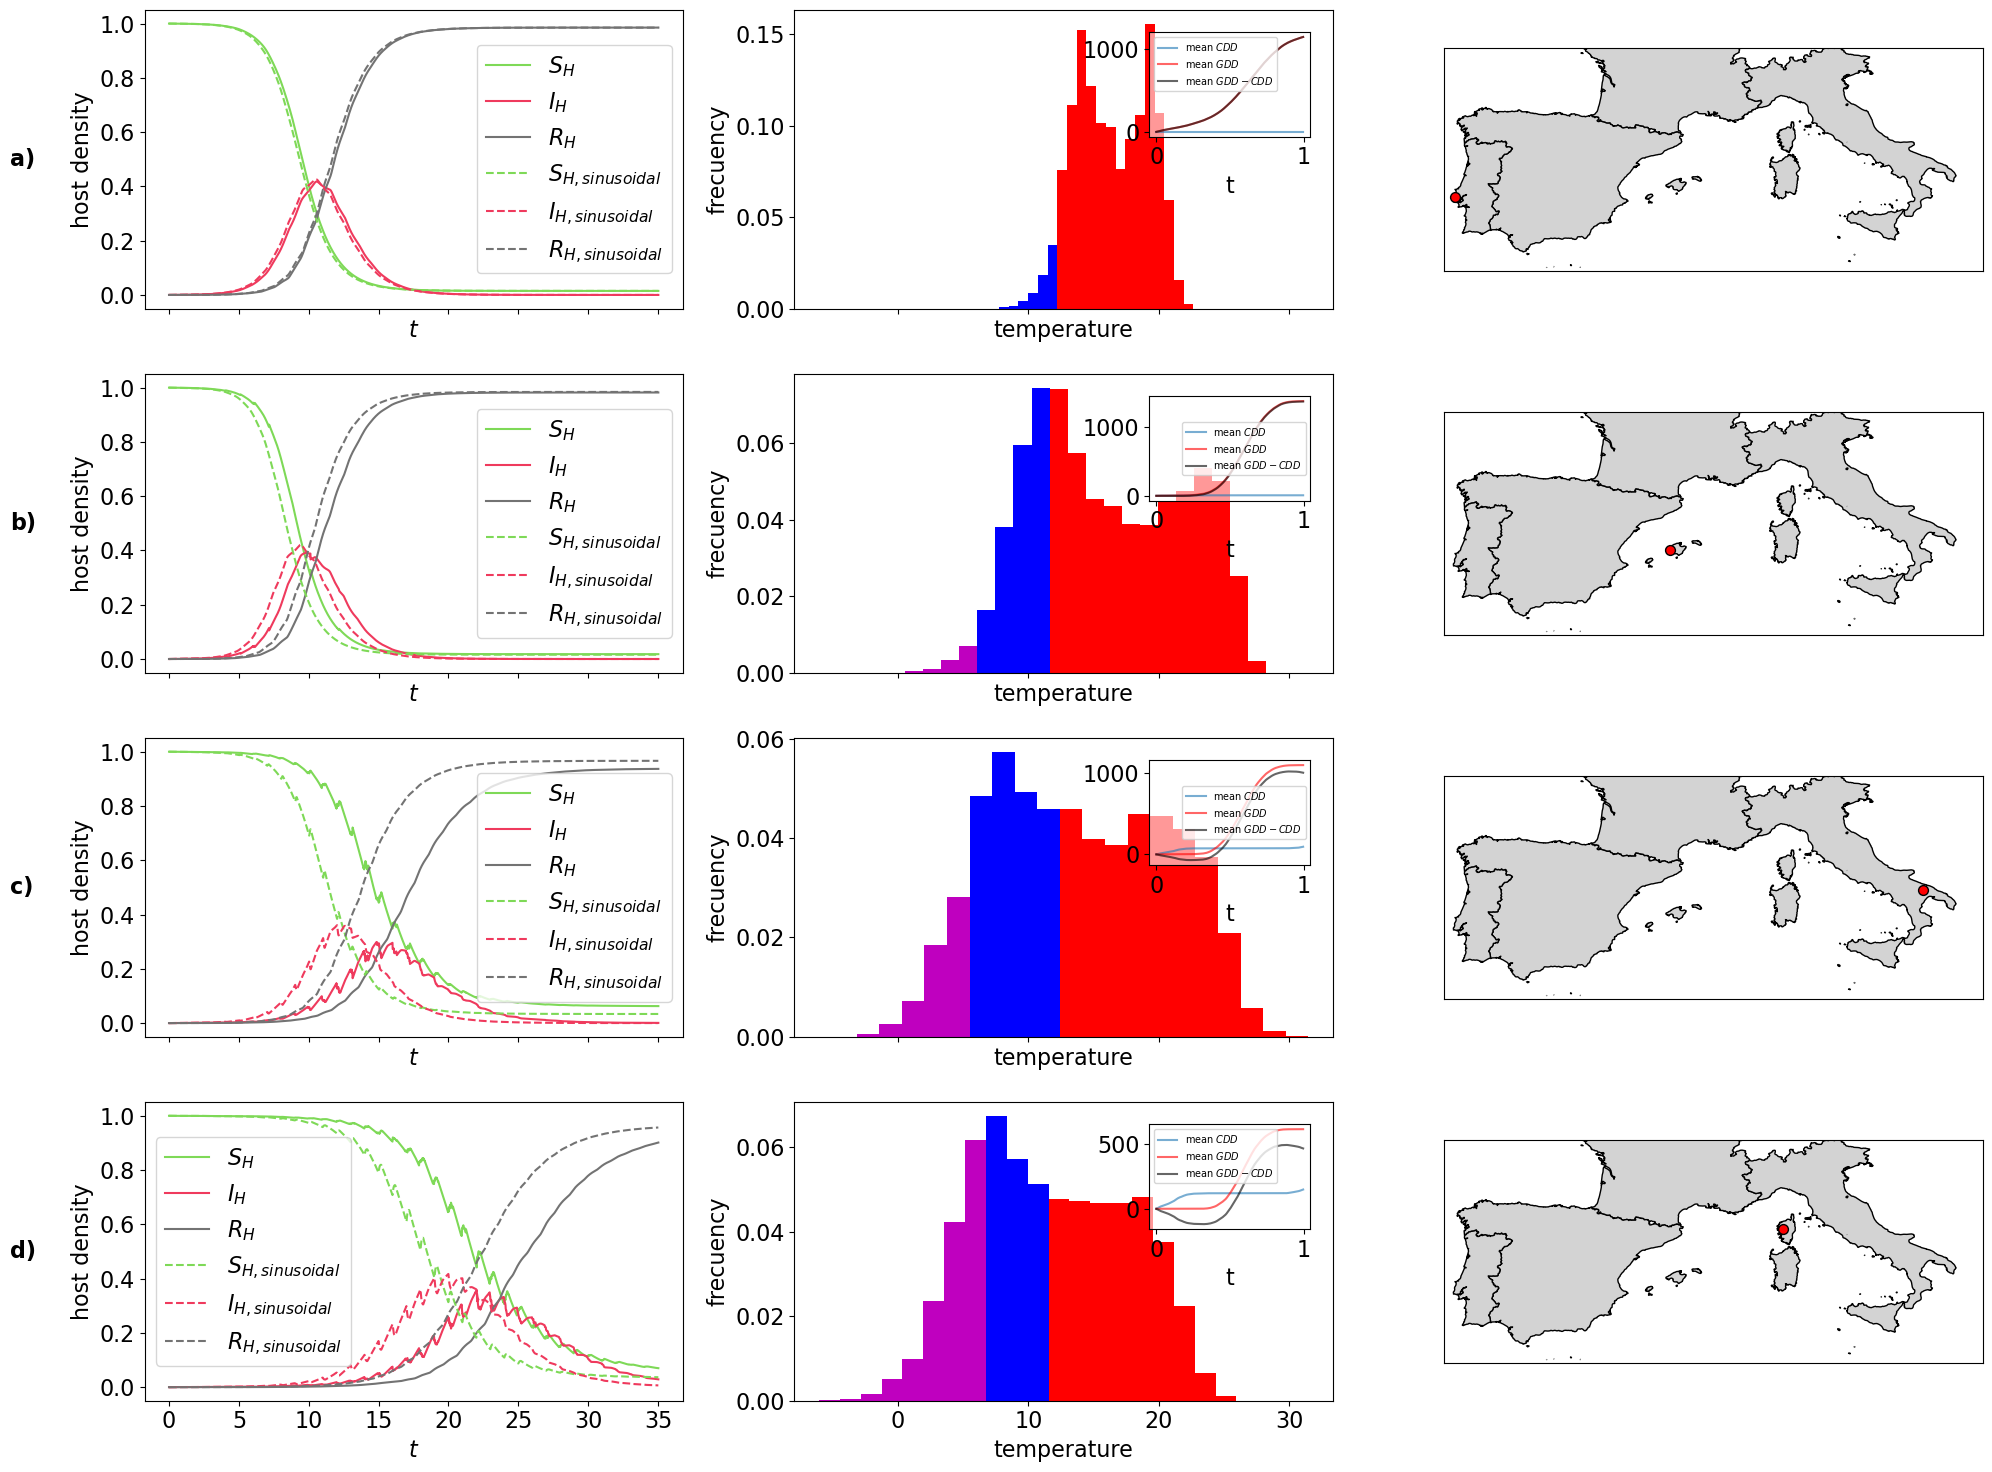

,points,$\bar{T}$,$\sigma ^ 2_{T}$,$\bar{f}$,$\frac{\bar{g}}{\bar{f}}$,$R_0}$,$a$,$b$,$\mu_{\delta}$,$\sigma_{\delta} ^ 2$,lat,lon
0,3870,16.395479,7.551122,1142.421297,0.000000,7.298417,12.910512,19.883521,-6.170335e-11,1.473287,38.950000,-9.420000
1,5709,16.065548,33.131466,1376.639226,0.005612,6.868667,8.458310,23.680838,-3.102385e-10,4.158031,39.550000,2.570000
2,5710,13.950302,44.038067,1090.447867,0.085971,6.788237,5.334091,22.576181,1.781281e-12,6.862781,40.874381,16.703334
3,5711,11.705500,33.613318,617.253197,0.243539,7.242410,4.314333,19.104628,1.787054e-10,6.261012,42.200229,8.864759


In [37]:
plt.rcParams.update({'font.size': 16})


### ----------------------------------------------
MGDD_R,n = 1500.0, 150
Delta_MGDD = MGDD_R/n

#----------------------------------------------

Alpha = 5.
beta = 1.
Gamma = 1.
mu = 1.
delta = mu

parameters = [beta,Alpha,MGDD_R,Gamma,mu,delta]

#----------------------------------------------

#----------------------------------------------
I_H_0 = 0.0
I_v_0 = 0.001

initial_conditions = [I_H_0,I_v_0]

#--------------------------------------------------------------------------------------

day_fraction = 7

selected_points = [3870,5709,new_point1,new_point2]
#df_summary_selected_points = df_summary.loc[selected_points]



fig, ax = plt.subplots(4,3,figsize=(20,15), sharex='col')

counter = 0
for point in selected_points:

    #-------------------------------------

    T_t = temperature_dataframe_wide.loc[point].values[:]
    lat,lon = temperature_dataframe[temperature_dataframe.points == point][['lat','lon']].iloc[0]

    #----------------------------------------------------------------

    sinusoidal_T,t,a,b = get_sinusoidal_fit(T_t)


    X,times=Vector_borne_ms(parameters,initial_conditions,T_t,n,day_fraction,1,1)
    X_s,times_s=Vector_borne_ms(parameters,initial_conditions,sinusoidal_T,n,day_fraction,1,1)

    ax[counter,0].plot(times,X[-4],"#7ed957")
    ax[counter,0].plot(times,np.sum(X[:n+1,:],axis=0),"#ef3a5d")
    ax[counter,0].plot(times,X[-3],"#737373")

    ax[counter,0].plot(times_s,X_s[-4],"#7ed957",linestyle='--')
    ax[counter,0].plot(times_s,np.sum(X_s[:n+1,:],axis=0),"#ef3a5d",linestyle='--')
    ax[counter,0].plot(times_s,X_s[-3],"#737373",linestyle='--')


    ax[counter,0].set_xlabel("$t$")
    ax[counter,0].set_ylabel("host density")


    ax[counter,0].legend(["$S_H$","$I_H$","$R_H$","$S_{H,sinusoidal}$","$I_{H,sinusoidal}$","$R_{H,sinusoidal}$"])


    #plot histogram

    frecuencys, bins, parches = ax[counter,1].hist(T_t, bins=20,density = True)

    centers= (bins[:-1] + bins[1:]) / 2

    gdd_centers = f(centers)
    cdd_centers = g(centers)

    gdd_centers_normed = gdd_centers / gdd_centers.sum() * frecuencys.sum()
    cdd_centers_normed = cdd_centers / cdd_centers.sum() * frecuencys.sum()




    # Colorear según el centro del bin
    for patch, left, right in zip(parches, bins[:-1], bins[1:]):
        centro = 0.5 * (left + right)

        if centro < 6:
            patch.set_facecolor('m')
        elif centro < 12:
            patch.set_facecolor('b')
        else:
            patch.set_facecolor('red')


    ax_in = inset_axes(
    ax[counter, 1],
    width="30%",
    height="35%",
    loc="upper right",
    borderpad=1
    )


    #get temperature functions

    f_t = f(T_t)*365
    g_t = g(T_t)*365

    n_years = int(len(f_t)/365)


    f_t = f_t[:365*n_years]
    f_t = f_t.reshape(n_years,365)


    g_t = g_t[:365*n_years]
    g_t = g_t.reshape(n_years,365)



    mean_f_t = np.mean(f_t,axis=0)
    std_f_t = np.std(f_t,axis=0)

    mean_g_t = np.mean(g_t,axis=0)
    std_g_t = np.std(g_t,axis=0)


    
    gdd = cumulative_trapezoid(mean_f_t,dx = 1/365)
    cdd = cumulative_trapezoid(mean_g_t,dx = 1/365)

    #plot insets

    year_time = np.array(range(364))*1/365

    ax_in.patch.set_alpha(0.6)
    ax_in.plot(year_time,cdd,alpha = 0.6)
    ax_in.plot(year_time,gdd,'r',alpha = 0.6)
    ax_in.plot(year_time,gdd-cdd, 'k',alpha = 0.6)

    ax_in.set_xlabel('t')
    ax_in.legend(['mean' + ' $CDD$','mean' + ' $GDD$','mean' + ' $GDD-CDD$' ],fontsize = 7)


    #plot the point in the map

    
    subset.plot(ax=ax[counter,2], color="lightgrey", edgecolor="black")

    ax[counter,2].scatter(
        lon, lat,
        color="red",
        s=50,
        edgecolor="black",
        linewidth=1,
        zorder=10
    )

    # Fix zoom to Mediterranean region
    ax[counter,2].set_xlim(-10, 20)
    ax[counter,2].set_ylim(35, 47)

    ax[counter,2].set_xticks([])
    ax[counter,2].set_yticks([])

    ax[counter,1].set_xlabel('temperature')
    ax[counter,1].set_ylabel('frecuency')

    
    counter+= 1


#label the plots

row_labels = ['a)', 'b)', 'c)', 'd)','e)']

for counter, point in enumerate(selected_points):
    # Your existing code ...
    
    # Add row label on the first column (or left side)
    ax[counter,0].text(
        -0.25, 0.5,   # x, y in axes coordinates
        row_labels[counter],
        transform=ax[counter,0].transAxes,
        fontsize=16,
        fontweight='bold',
        va='center'
    )




plt.tight_layout()

plt.savefig(f"figures/figure_5.pdf", dpi=300, bbox_inches="tight")

plt.show()

df_summary